In [3]:
import pandas as pd

df = pd.read_csv('CAUSAS_DE_MUERTE_HRSG_20260518.csv')

df.head()

,Municipio Defunción,Departamento Defunción,Área Defunción,Sitio Defunción,IPS,Sexo,Edad Fallecido,Diagnóstico A,Diagnóstico B,Diagnóstico C,Diagnóstico D,Otros Estados Patológicos,Otros Estados Patológicos 2,Fecha de defunción
0,SAN GIL,SANTANDER,CABECERA MUNICIPAL,HOSPITAL/CLÍNICA,E.S.E. HOSPITAL REGIONAL SAN GIL,INDETERMINADO,0,ABORTO POR CORIOAMNIONITIS,AUSENCIA DE CONTROLES PRENATALES,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,03/01/2025
1,SAN GIL,SANTANDER,CABECERA MUNICIPAL,HOSPITAL/CLÍNICA,E.S.E. HOSPITAL REGIONAL SAN GIL,MASCULINO,91,ANOXIA ANOXICA,SINDROME DE DIFICULTAD RESPIRATORIO AGUDA,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,ALZHAIMER,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,03/01/2025
2,SAN GIL,SANTANDER,CABECERA MUNICIPAL,HOSPITAL/CLÍNICA,E.S.E. HOSPITAL REGIONAL SAN GIL,FEMENINO,76,ENFERMEDAD CEREBROVASCULAR HEMORRÁGICA,HIPERTENSION ARTERIAL,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,04/01/2025
3,SAN GIL,SANTANDER,CABECERA MUNICIPAL,HOSPITAL/CLÍNICA,E.S.E. HOSPITAL REGIONAL SAN GIL,MASCULINO,64,SEPSIS URINARIA,INFECCION DE VIAS URINARIAS,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,ENFERMEDAD RENAL CRONICA,HIPERTENSION ARTERIAL,07/01/2025
4,SAN GIL,SANTANDER,CABECERA MUNICIPAL,HOSPITAL/CLÍNICA,E.S.E. HOSPITAL REGIONAL SAN GIL,FEMENINO,57,CHOQUE DISTRIBUTIVO,FALLA RENAL Y HEPATICA,CIRROSIS HEPATICA DESCOMPENSADA,CIRROSIS HEPATICA ALCOHOLICA,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,SIN ESTADOS PATOLÓGICOS PREEXISTENTE,08/01/2025


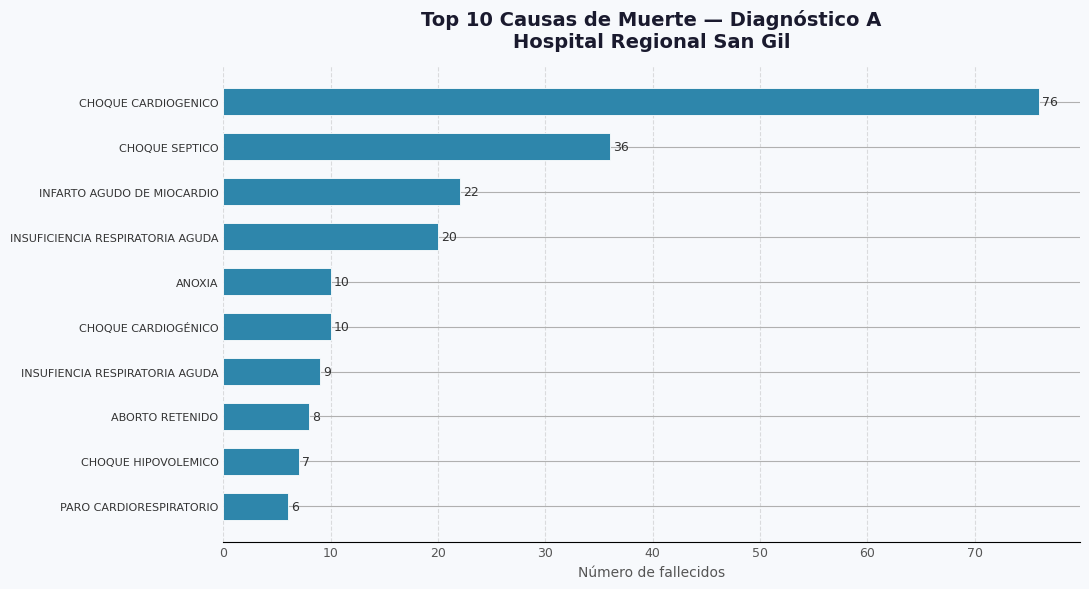

✔ Gráfica 1 guardada: grafica1_top_causas.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt



# ── Top 10 causas ─────────────────────────────────────────────────────────────
top_causas = (
    df['Diagnóstico A']
    .value_counts()
    .head(10)
    .sort_values()
)

FONDO = '#F7F9FC'
COLOR = '#2E86AB'

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(FONDO)
ax.set_facecolor(FONDO)

bars = ax.barh(top_causas.index, top_causas.values, color=COLOR,
               edgecolor='white', linewidth=0.6, height=0.6)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{int(w)}', va='center', ha='left', fontsize=9, color='#333333')

ax.set_title('Top 10 Causas de Muerte — Diagnóstico A\nHospital Regional San Gil',
             fontsize=14, fontweight='bold', pad=14, color='#1A1A2E')
ax.set_xlabel('Número de fallecidos', fontsize=10, color='#555555')
ax.tick_params(axis='y', labelsize=8, colors='#333333')
ax.tick_params(axis='x', labelsize=9, colors='#555555')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('grafica1_top_causas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Gráfica 1 guardada: grafica1_top_causas.png")

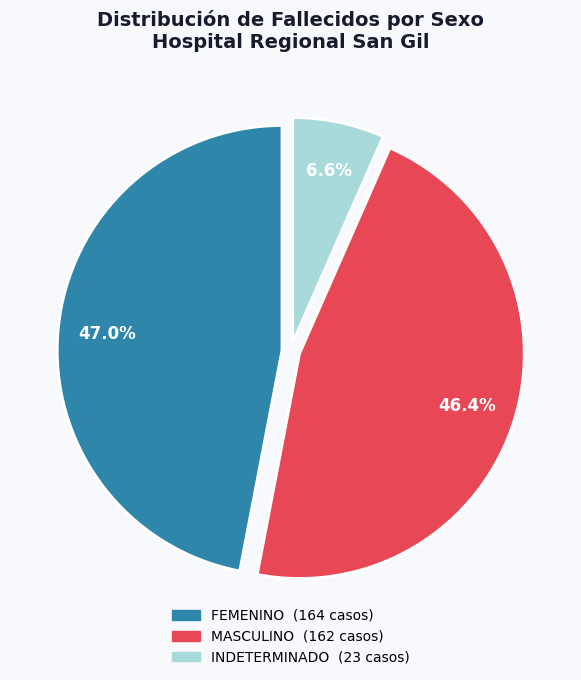

✔ Gráfica 2 guardada: grafica2_distribucion_sexo.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches



# ── Distribución por sexo 
sexo_counts = df['Sexo'].value_counts()

FONDO = '#F7F9FC'
colores = ['#2E86AB', '#E84855', '#A8DADC']
explode = [0.04] * len(sexo_counts)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(FONDO)

wedges, texts, autotexts = ax.pie(
    sexo_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=colores[:len(sexo_counts)],
    explode=explode,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.78
)

for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

leyenda = [
    mpatches.Patch(color=colores[i],
                   label=f'{sexo_counts.index[i]}  ({sexo_counts.values[i]} casos)')
    for i in range(len(sexo_counts))
]
ax.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=10, frameon=False)

ax.set_title('Distribución de Fallecidos por Sexo\nHospital Regional San Gil',
             fontsize=14, fontweight='bold', pad=16, color='#1A1A2E')

plt.tight_layout()
plt.savefig('grafica2_distribucion_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Gráfica 2 guardada: grafica2_distribucion_sexo.png")

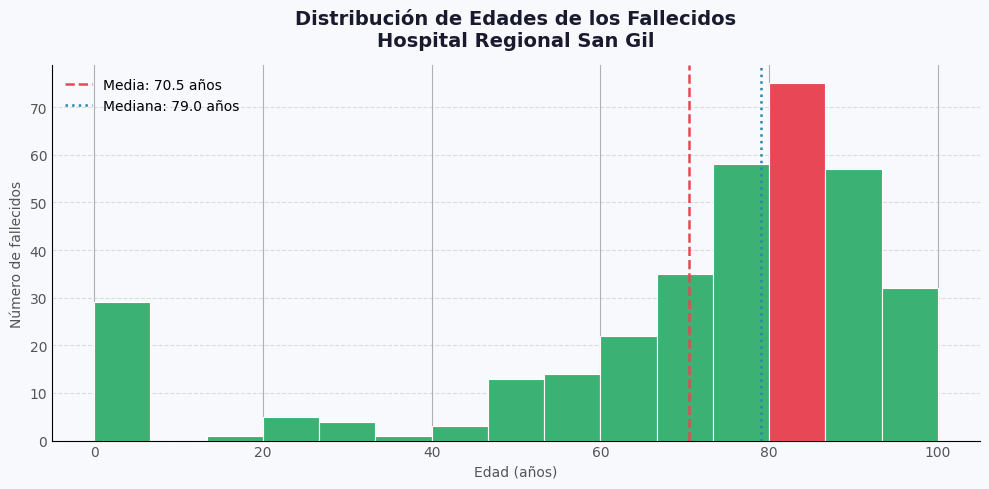

✔ Gráfica 3 guardada: grafica3_distribucion_edades.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df['Edad Fallecido'] = pd.to_numeric(df['Edad Fallecido'], errors='coerce')

# ── Histograma de edades 
edades = df['Edad Fallecido'].dropna()

FONDO = '#F7F9FC'

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(FONDO)
ax.set_facecolor(FONDO)

n, bins, patches = ax.hist(edades, bins=15, color='#3BB273',
                            edgecolor='white', linewidth=0.8)

# Resaltar la barra más alta
patches[n.argmax()].set_facecolor('#E84855')

# Líneas de media y mediana
media = edades.mean()
mediana = edades.median()
ax.axvline(media, color='#E84855', linestyle='--', linewidth=1.8,
           label=f'Media: {media:.1f} años')
ax.axvline(mediana, color='#2E86AB', linestyle=':', linewidth=1.8,
           label=f'Mediana: {mediana:.1f} años')

ax.set_title('Distribución de Edades de los Fallecidos\nHospital Regional San Gil',
             fontsize=14, fontweight='bold', pad=14, color='#1A1A2E')
ax.set_xlabel('Edad (años)', fontsize=10, color='#555555')
ax.set_ylabel('Número de fallecidos', fontsize=10, color='#555555')
ax.legend(fontsize=10, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#555555')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('grafica3_distribucion_edades.png', dpi=150, bbox_inches='tight')
plt.show()
print("✔ Gráfica 3 guardada: grafica3_distribucion_edades.png")
